In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import use_solver, spsolve

In [2]:
import sys
sys.path.insert(1, '../Utilities/')
from stefan import Stefan1D

In [3]:
from matplotlib import rc
rc('xtick', direction='in', top=True)
rc('ytick', direction='in', right=True)

In [4]:
c = 0.045 * 0.2
c

0.009

In [5]:
Pr = 56.2
Ra = 3.27 *1e5

xref = 0.015
Uref = Pr/np.sqrt(Ra)
tref = xref/Uref
tref

np.float64(0.15262610450707254)

In [6]:
problem = Stefan1D(
    Th=1,
    Tc=-0.01,
    Tf=0,
    L=2180/0.045,
    alpha=9.e-8,
    c=2180,
    xref=0.015,
    tref=50
)


Ste = problem.Ste
Fo = problem.Fo
Th, Tc, T = problem.Th, problem.Tc, problem.T
print('Ste: %.3f, Fo: %.6f, Th: %.3f, Tc: %.3f' % (Ste, Fo, Th, Tc))

Ste: 0.045, Fo: 0.020000, Th: 1.000, Tc: -0.010


In [7]:
problem.lam

np.float64(0.1487472510478243)

In [7]:
delta = 0.01
x0, xn = 0., 1.
t0, tn = 5e-2, 1.

In [8]:
def r(T):
    N = Fo
    D = 1. + (1./Ste)* (1./(2* delta))* (1. - np.tanh(T/delta)**2)
    return N/D

def dr(T):
    N = Fo* np.tanh(T/delta)* (1. - np.tanh(T/delta)**2)
    D = Ste* (delta**2)* (1. + (1./Ste)* (1./(2* delta))* (1. - np.tanh(T/delta)**2))**2
    return N/D

In [10]:
def lap_matrix(n, a=-2):
    """Laplacian matrix"""
    
    ones = np.ones(n - 2)
    d = np.hstack([a, -2* ones, a])
    ds = np.hstack([0, ones])
    di = np.hstack([ones, 0])

    return diags([di, d, ds], [-1, 0, 1])

In [11]:
def jacobien(theta, k, A):
    
    d  = 1. - k * dr(theta) * (A @ theta) + 2* k * r(theta)
    d[0], d[-1] = 1., 1.
    
    ds = - k * r(theta[:-1])
    ds[0] = 0.
    
    di = - k * r(theta[1:])
    di[-1] = 0.
    
    return diags([di, d, ds], [-1, 0, 1]).tocsr()

In [12]:
def newton(u0, k, max_iter=1000, tolerance=1e-9):

    f = lambda x, k, A: x - k* r(x)* (A @ x)
    g = lambda x, k, A: x + k* r(x)* (A @ x)
    
    v = u0
    for _ in range(max_iter):

        A = lap_matrix(u0.shape[0], a=0.)
        jac = jacobien(v, k, A)
        F = f(v, k, A) - g(u0, k, A)
        
        use_solver(useUmfpack=False)
        d = spsolve(jac, F)

        # Newton update
        v = v - d
        norm = np.linalg.norm(d, ord=np.inf)
        
        if norm < tolerance:
            return v
        
    print(f"Newton iterations didn't converge, norm: {norm:.3e}")

In [13]:
def save_sol(ti, x, u, log, save_x):
    x = x.reshape(-1, 1)[::save_x]
    u = u.reshape(-1, 1)[::save_x]
    solution = (
        ti* np.ones_like(x), 
        x,
        u
    )
    solution = np.hstack(solution)
    log.append(solution)
    return log

In [14]:
def solve(nt, nx, save_t=1, save_x=1):
    
    t = np.linspace(t0, tn, nt)
    x = np.linspace(x0, xn, nx)
    dx = (xn - x0)/(nx - 1)
    dt = (tn - t0)/(nt - 1)
    k = dt/(2* dx**2)
    
    u0 = T(t[0], x)
    save = list()

    log = list()
    for i, ti in enumerate(t):
        u1 = newton(u0, k)

        # save solution
        if i % save_t == 0:
            log = save_sol(ti, x, u0, log, save_x)
        
        # time update
        u0 = u1

    log = save_sol(ti, x, u0, log, save_x)
    log = np.vstack(log)
    return log

In [15]:
%%time
nt = 10001
nx = 10001
solution = solve(nt, nx, save_t=100, save_x=25)

CPU times: user 1min 15s, sys: 19.7 s, total: 1min 34s
Wall time: 1min 34s


In [16]:
x = np.linspace(x0, xn, nx)
t = np.linspace(t0, tn, nt)
print(x[::25].shape)
print(t[::100].shape)

(401,)
(101,)


In [23]:
n0 = 401
ics = solution[:n0, :]

In [24]:
## Convert to 2D data (for PCM):

t0 = solution[0, 0]
x0, y0 = np.meshgrid(solution[:n0, 1], solution[:n0, 1])
T0, _ = np.meshgrid(solution[:n0, 2], solution[:n0, 2])


def adapt(j, pas1=2, pas2=25):
    i = list(range(j)[::pas1]) + list(range(j, n0)[::pas2])
    i[-1] = n0 - 1
    return np.meshgrid(i, i)

i, j = adapt(15, pas1=1) 
j = np.linspace(0, n0-1, len(i), dtype=int)
_, j = np.meshgrid(j, j)

x0 = x0[j, i]
y0 = y0[j, i]
T0 = T0[j, i]
t0 = t0* np.ones_like(x0)

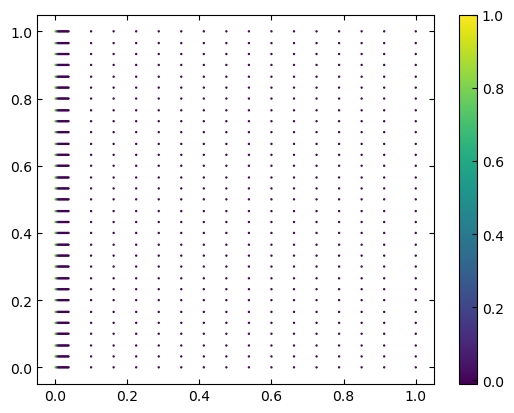

In [25]:
ct = plt.scatter(x0, y0, c=T0, s=.5)
plt.colorbar(ct)
plt.show()

In [28]:
u0 = np.zeros_like(T0)

data = np.hstack([
    t0.reshape(-1, 1),
    x0.reshape(-1, 1),
    y0.reshape(-1, 1),
    u0.reshape(-1, 1),
    u0.reshape(-1, 1),
    T0.reshape(-1, 1)
])

In [31]:
header = "Ste=%f, Fo=%f, delta=%f\nt, x, T"%(Ste, Fo, delta)
np.savetxt(
    'Stefan2D_0.045', 
    data,
    delimiter = ',\t',
    header=header
)

# Convergence curve

In [13]:
%%time

U = []
h = []

j = 1

for _ in range(9) :
    
    n = j* 100 + 1
    print(1/n)
    sol = solve(n, n)
    
    _, _, u = np.hsplit(sol, 3)
    
    u = u.reshape(-1, n)
    
    l = range(0, n, j)
    
    U.append(u[l, l])
    h.append(1/n)
    
    j = 2* j

0.009900990099009901
0.004975124378109453
0.0024937655860349127
0.0012484394506866417
0.0006246096189881324
0.00031240237425804435
0.0001562255897516013
7.81188969611749e-05
3.906097418069607e-05
CPU times: user 7min 54s, sys: 2min 21s, total: 10min 15s
Wall time: 10min 25s


In [14]:
def ERRL2(U, Uex) :
    return np.linalg.norm(U - Uex, 2) / np.linalg.norm(Uex, 2)

In [15]:
err = []

for i, u in enumerate(U[:-1]) :
    e = ERRL2(u.flatten(), U[-1].flatten())
    err.append(e)
    print('errL2 : %.3e' %(e))

errL2 : 1.629e-03
errL2 : 6.659e-05
errL2 : 1.723e-05
errL2 : 4.292e-06
errL2 : 1.070e-06
errL2 : 2.642e-07
errL2 : 6.291e-08
errL2 : 1.258e-08


In [16]:
h = h[:-1]

In [17]:
h

[0.009900990099009901,
 0.004975124378109453,
 0.0024937655860349127,
 0.0012484394506866417,
 0.0006246096189881324,
 0.00031240237425804435,
 0.0001562255897516013,
 7.81188969611749e-05]

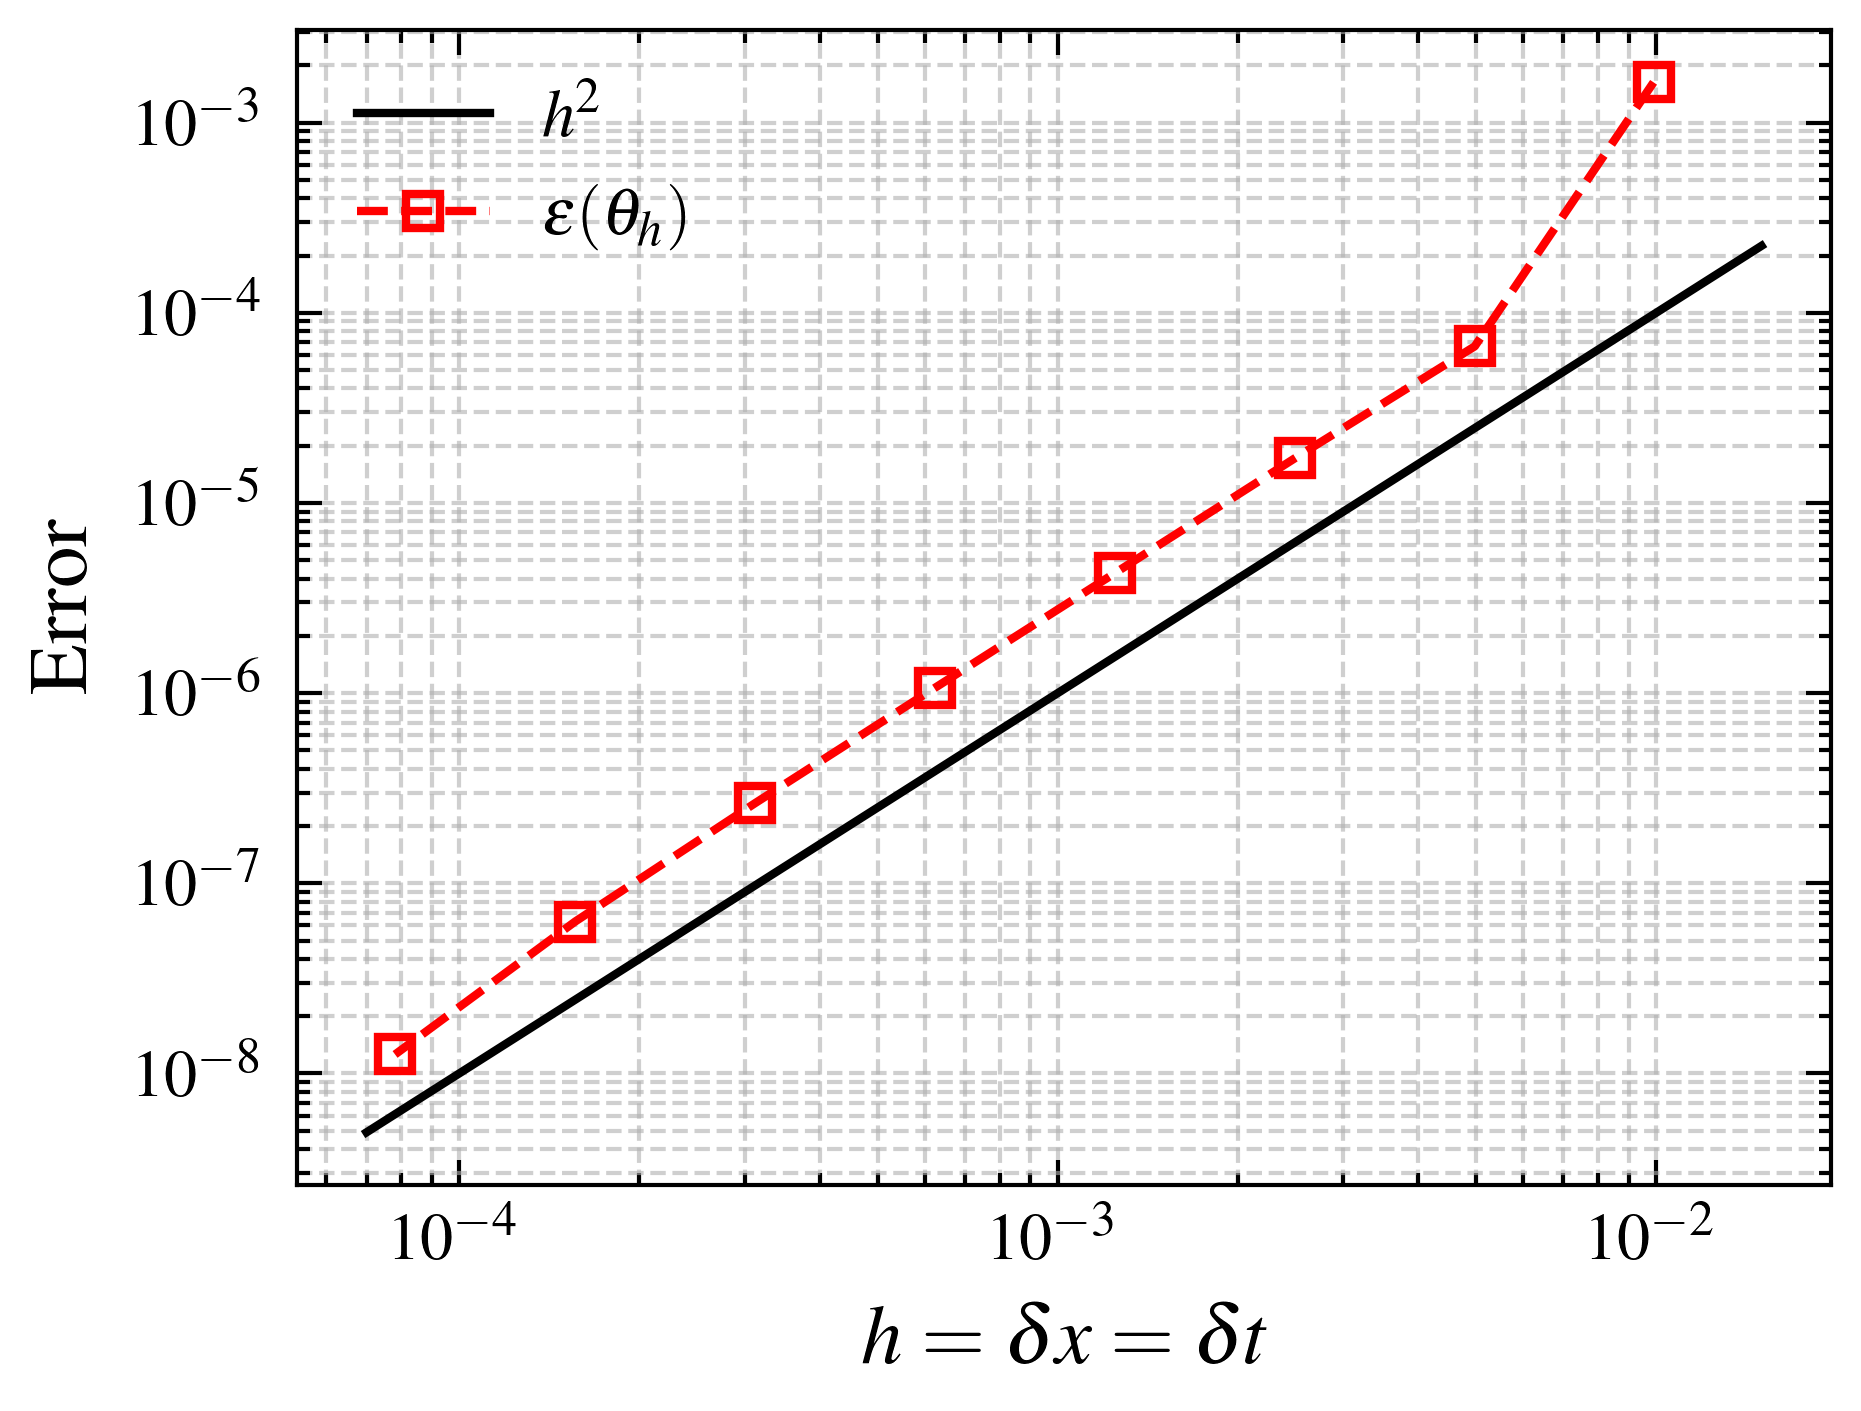

In [26]:
fig, ax = plt.subplots(1, 1)

plt.xscale('log')
plt.yscale('log')

ax.grid(True, which='both', alpha = .6, ls='dashed')

plt.plot(np.array([0.015, 0.00007]), np.array([0.015, 0.00007])**2, 'k', alpha=1, label = '$h^2$')
plt.plot(h, err, 'r--s', markersize=4, markerfacecolor="none", label = r'$\epsilon(\theta_h)$')

ax.set_xlabel('$h = \delta x = \delta t$', fontsize = 10)
ax.set_ylabel('Error', fontsize = 10)

plt.legend()
plt.savefig('FD.pdf', bbox_inches ='tight')
plt.savefig('FD.png', bbox_inches ='tight')
plt.show()

###  Reference solution

In [14]:
n = 500

In [15]:
%%time

sol_ref = Crank_Nicolson(500, 500)

/home/bmadir/miniconda3/envs/jupyter/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


CPU times: user 714 ms, sys: 8.09 ms, total: 722 ms
Wall time: 736 ms


In [16]:
np.savetxt('../Utilities/sol_ref_%.3f_%.3f.txt' %(Ste, Pe), sol_ref, delimiter = '\t')

In [21]:
x, t, u = np.hsplit(sol_ref, 3)

In [22]:
x = x.reshape(-1, n)
t = t.reshape(-1, n)
u = u.reshape(-1, n)

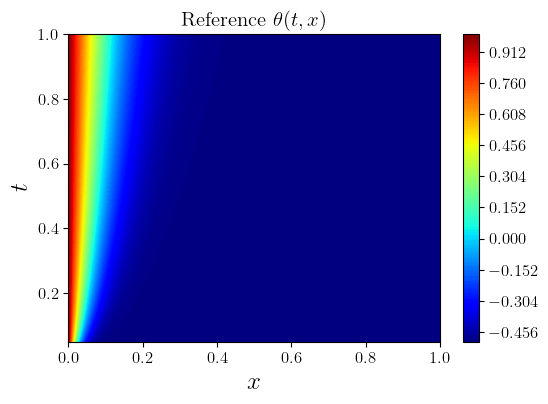

In [23]:
fig, ax = plt.subplots(1, 1)

ctf  = ax.contourf(x, t, u, 200, cmap='jet')
cb = fig.colorbar(ctf, shrink=1, ax = ax)

ax.set_xlabel('$x$', fontsize=18)
ax.set_ylabel('$t$', fontsize=18)
ax.set_title(r'Reference $\theta(t, x)$', fontsize=15)

plt.show()

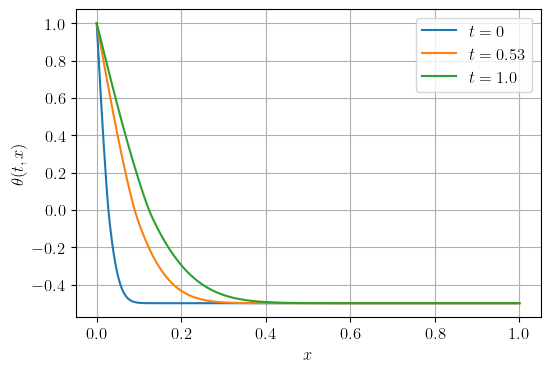

In [24]:
plt.ylabel(r'$\theta(t, x)$')
plt.xlabel('$x$')

plt.grid(True)
plt.plot(x[0, :], u[0, :], label = '$t = 0$')
plt.plot(x[0, :], u[250, :], label = f'$t = {t[250, 0] : .2f}$')
plt.plot(x[0, :], u[-1, :], label = f'$t = {t[-1, 0]}$')

plt.legend()
plt.show()